# Critical batch size

Steps-to-target vs batch size (McCandlish-style). Distinctive for Sven since its update rank is capped at B. Sven vs AdamW on MNIST and nanoGPT.

> Loads the fresh Gram-backend results. Robust to partial data (plots whatever has finished).

In [1]:
import sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '.')
from style import load_results, average_over_seeds, set_style
from analysis_helpers import add_derived, best_per_method, valid, loss_curve, steps_to_target, method_order
from pathlib import Path
set_style()
PLOT_DIR = Path('plots/critbatch'); PLOT_DIR.mkdir(parents=True, exist_ok=True)
def sven_color(m): return 'k' if m=='Sven' else None
def sven_lw(m):    return 2.6 if m=='Sven' else 1.6

In [2]:
SCANS={'MNIST':'exp_critbatch_mnist','nanoGPT':'exp_critbatch_nanogpt'}
data={}
for t,n in SCANS.items():
    try: data[t]=add_derived(load_results(n))
    except FileNotFoundError: print('missing',n)

Loaded 84 runs from ../experiment_results/exp_critbatch_mnist/ (directory format, slim)
Loaded 84 runs from ../experiment_results/exp_critbatch_nanogpt/ (directory format, slim)


### Steps-to-target vs batch size

Target = 1.2x the best final val loss seen in that study (edit `MULT`).

findfont: Font family 'arial' not found.
findfont: Font family ['arial'] not found. Falling back to DejaVu Sans.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'ari

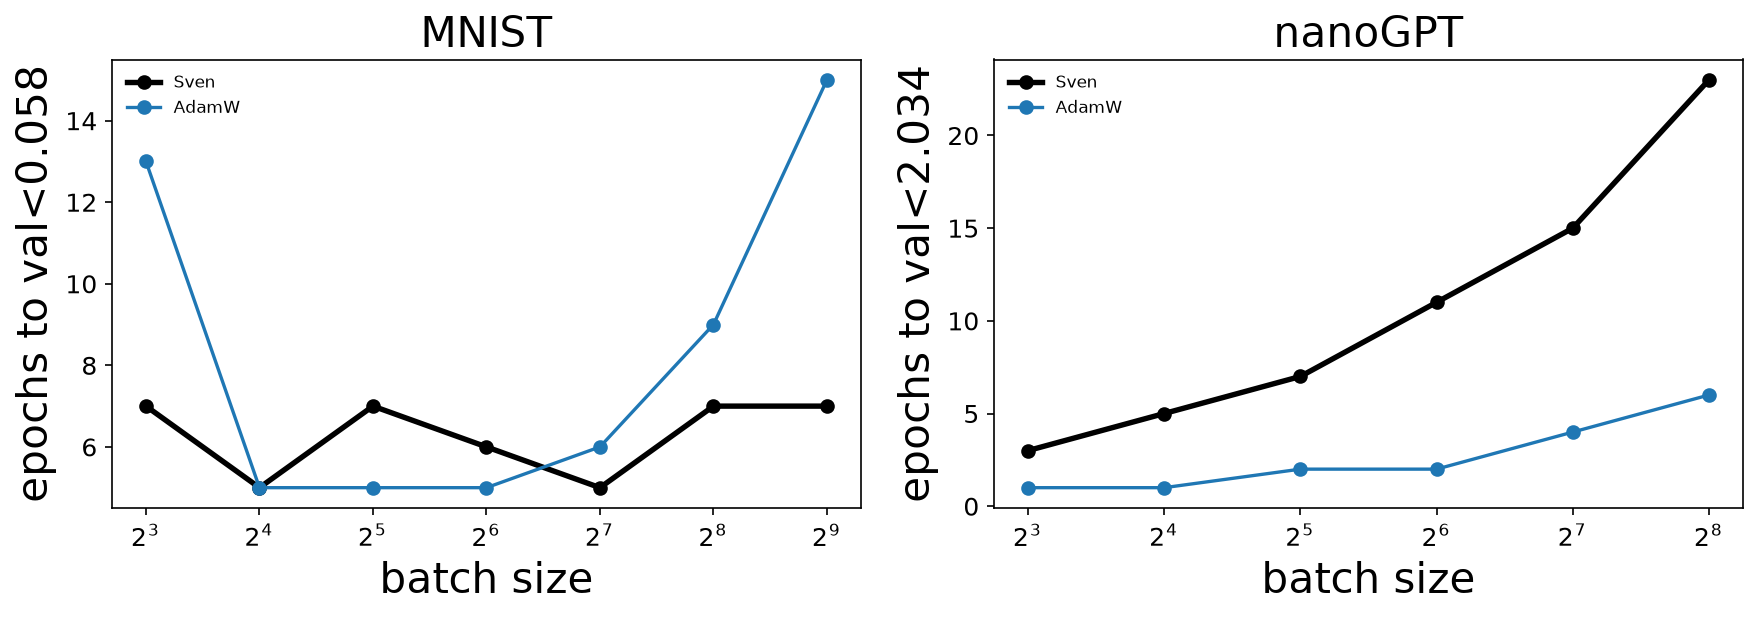

In [3]:
MULT=1.2
fig,axes=plt.subplots(1,len(data),figsize=(6*len(data),4.4),squeeze=False)
for ax,(t,df) in zip(axes[0],data.items()):
    d=valid(df); target=d['final_val_loss'].min()*MULT
    d=d.copy(); d['s2t']=d.apply(lambda r: steps_to_target(r, target, 'val'), axis=1)
    d=d[d['s2t'].notna()]
    if d.empty: ax.set_title(f'{t}: no run hit target'); continue
    best=d.loc[d.groupby(['method','batch_size'])['s2t'].idxmin()]
    for m in method_order(best['method'].unique()):
        s=best[best.method==m].sort_values('batch_size')
        ax.plot(s['batch_size'], s['s2t'], marker='o', color=sven_color(m), lw=sven_lw(m), label=m)
    ax.set_xscale('log',base=2); ax.set_xlabel('batch size'); ax.set_ylabel(f'epochs to val<{target:.3f}')
    ax.set_title(t); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOT_DIR/'critical_batch.pdf',bbox_inches='tight'); plt.show()